# Ceridwen differential-age cosmic chronometer

- Repeats the Borghi bin-and-difference estimator.
- Propagates Ceridwen age posteriors with galaxy bootstrap resampling.
- Treats the result as an exploratory consistency test.
- Mass-weighted ages differ from Lick SSP-equivalent ages.
- The SFH age ceiling inherits Ceridwen's Planck-2018 cosmology.

In [1]:
import json
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation

RESULT_ROOT = Path.cwd().resolve()
assert RESULT_ROOT.name == "rtx-5060-dr2-quiescent-full-spectrum"
PROJECT_ROOT = RESULT_ROOT.parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

from src.chronometer import (
    hubble_from_age_difference,
    hubble_uncertainty_from_age_errors,
    inverse_variance_combine,
)

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 20260901
N_BOOTSTRAP = 10_000
SIGMA_SPLIT = 215.0
Z_EDGES = np.linspace(0.6, 0.9, 5)

## Load validated posterior ages

- One row represents one unique LEGA-C galaxy.
- Age draws are mass-weighted SFH lookback ages.

In [2]:
target_manifest = json.loads((RESULT_ROOT / "targets.json").read_text())
rows = []
age_draws = []

for target in target_manifest["targets"]:
    target_dir = RESULT_ROOT / f"{target['object_id']}-{target['spect_id']}"
    derived_path = target_dir / "ceridwen_derived_outputs.h5"
    with h5py.File(derived_path, "r") as result:
        draws = np.asarray(result["sfh/mass_weighted_age_gyr"], dtype=float)
        diagnostics = result["diagnostics"].attrs
        assert bool(diagnostics["passed"])
        assert draws.shape == (400,)
        assert int(result.attrs["num_live"]) == 500
        assert float(result.attrs["logZ_tol"]) == -5.0
        rows.append({
            "object_id": int(result.attrs["object_id"]),
            "target_id": str(result.attrs["target_id"]),
            "redshift": float(result.attrs["redshift"]),
            "sigma_star_kms": float(result.attrs["sigma_star_kms"]),
            "age_q16_gyr": float(np.quantile(draws, 0.16)),
            "age_median_gyr": float(np.median(draws)),
            "age_q84_gyr": float(np.quantile(draws, 0.84)),
            "posterior_weight_ess": float(diagnostics["posterior_weight_ess"]),
            "joint_chi2_per_datum": float(diagnostics["joint_chi2"] / diagnostics["joint_ndof"]),
            "spectrum_chi2_per_datum": float(diagnostics["spectrum_chi2"] / diagnostics["spectrum_ndof"]),
            "photometry_chi2_per_datum": float(diagnostics["photometry_chi2"] / diagnostics["photometry_ndof"]),
        })
        age_draws.append(draws)

galaxies = pd.DataFrame(rows)
age_draws = np.asarray(age_draws)
assert len(galaxies) == target_manifest["unique_objects"] == 187
assert galaxies["object_id"].is_unique

galaxies["age_minus_gyr"] = galaxies["age_median_gyr"] - galaxies["age_q16_gyr"]
galaxies["age_plus_gyr"] = galaxies["age_q84_gyr"] - galaxies["age_median_gyr"]
galaxies.describe(percentiles=[0.16, 0.5, 0.84]).T

,count,mean,std,min,16%,50%,84%,max
object_id,187.0,168833.176471,62197.511329,27068.000000,105330.720000,180774.000000,232907.280000,259737.000000
redshift,187.0,0.753476,0.102245,0.602600,0.672816,0.729200,0.889821,0.987383
sigma_star_kms,187.0,203.640108,47.242964,80.599998,161.012004,203.800003,252.679997,312.100006
age_q16_gyr,187.0,3.206935,0.949870,0.052083,2.755747,2.997429,4.181370,6.179693
age_median_gyr,187.0,3.378343,1.013347,0.172735,2.845413,3.019782,4.460569,6.287905
age_q84_gyr,187.0,3.584793,1.053896,0.723746,2.931112,3.151850,4.722147,6.334304
posterior_weight_ess,187.0,3581.247371,301.737800,2964.776843,3310.323532,3550.649762,3871.704353,4857.735908
joint_chi2_per_datum,187.0,1.181601,0.209114,0.945935,1.084035,1.139285,1.212907,2.689030
spectrum_chi2_per_datum,187.0,1.159089,0.211989,0.929008,1.065914,1.119690,1.187712,2.684886
photometry_chi2_per_datum,187.0,7.897679,5.297772,1.398974,2.997011,7.035969,13.014956,28.770911


## Match Borghi's baseline grouping

- Split velocity dispersion at 215 km/s.
- Use four fixed redshift bins from 0.6–0.9.
- Estimate median uncertainty as NMAD divided by sqrt(N).

In [3]:
analysis = galaxies.loc[galaxies["redshift"].between(0.6, 0.9, inclusive="left")].copy()
analysis["sigma_group"] = np.where(
    analysis["sigma_star_kms"] > SIGMA_SPLIT, "higher sigma", "lower sigma"
)
analysis["z_bin"] = pd.cut(
    analysis["redshift"], Z_EDGES, labels=[1, 2, 3, 4],
    include_lowest=True, right=False,
).astype(int)

bin_rows = []
for (sigma_group, z_bin), group in analysis.groupby(["sigma_group", "z_bin"], observed=True):
    ages = group["age_median_gyr"].to_numpy()
    bin_rows.append({
        "sigma_group": sigma_group,
        "z_bin": int(z_bin),
        "n": len(group),
        "z_median": group["redshift"].median(),
        "age_median_gyr": np.median(ages),
        "age_nmad_gyr": median_abs_deviation(ages, scale="normal"),
        "age_median_error_gyr": median_abs_deviation(ages, scale="normal") / np.sqrt(len(group)),
    })

binned = pd.DataFrame(bin_rows).sort_values(["sigma_group", "z_bin"]).reset_index(drop=True)
binned

,sigma_group,z_bin,n,z_median,age_median_gyr,age_nmad_gyr,age_median_error_gyr
0,higher sigma,1,14,0.619850,3.218901,1.196702,0.319832
1,higher sigma,2,31,0.724400,3.023236,0.254258,0.045666
2,higher sigma,3,3,0.779201,3.019782,0.020311,0.011727
3,higher sigma,4,14,0.843962,4.037123,1.031485,0.275676
4,lower sigma,1,19,0.647900,3.111492,0.319062,0.073198
5,lower sigma,2,59,0.698464,3.012981,0.165726,0.021576
6,lower sigma,3,9,0.765689,3.008995,0.146936,0.048979
7,lower sigma,4,15,0.851000,2.943686,1.027038,0.265180


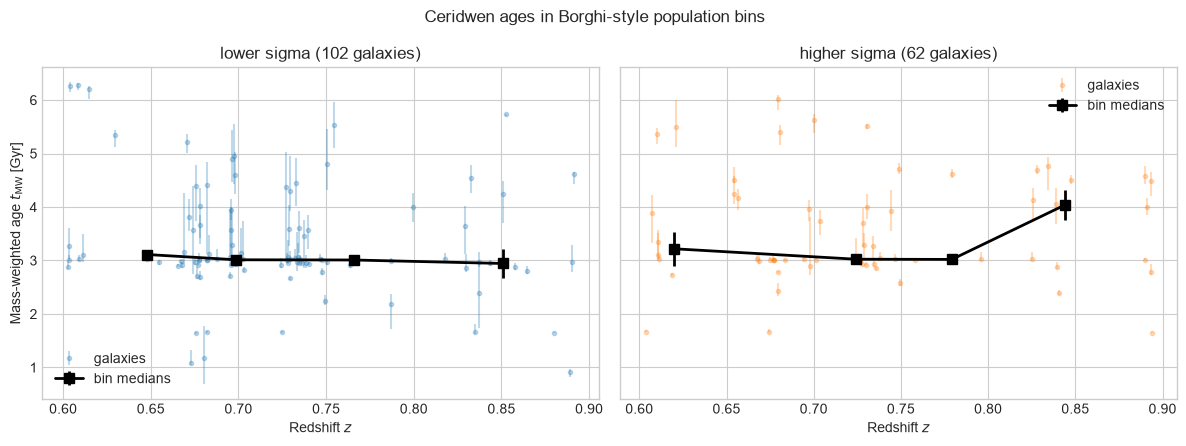

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {"lower sigma": "tab:blue", "higher sigma": "tab:orange"}
for axis, sigma_group in zip(axes, colors):
    group = analysis.loc[analysis["sigma_group"] == sigma_group]
    bins = binned.loc[binned["sigma_group"] == sigma_group]
    axis.errorbar(
        group["redshift"], group["age_median_gyr"],
        yerr=[group["age_minus_gyr"], group["age_plus_gyr"]],
        fmt="o", ms=3, alpha=0.28, color=colors[sigma_group], label="galaxies",
    )
    axis.errorbar(
        bins["z_median"], bins["age_median_gyr"],
        yerr=bins["age_median_error_gyr"], fmt="s-", ms=7, lw=2,
        color="black", label="bin medians",
    )
    axis.set(title=f"{sigma_group} ({len(group)} galaxies)", xlabel="Redshift $z$")
    axis.legend()
axes[0].set_ylabel(r"Mass-weighted age $t_{\rm MW}$ [Gyr]")
fig.suptitle("Ceridwen ages in Borghi-style population bins")
fig.tight_layout()
plt.show()

## Derive four differential-age estimates

- Compare alternate bins to keep estimates independent.
- Combine estimates using inverse statistical variance.

In [5]:
estimate_rows = []
for sigma_group in ["lower sigma", "higher sigma"]:
    table = binned.loc[binned["sigma_group"] == sigma_group].set_index("z_bin")
    for low_bin, high_bin in [(1, 3), (2, 4)]:
        low = table.loc[low_bin]
        high = table.loc[high_bin]
        z_eff, hubble = hubble_from_age_difference(
            low["z_median"], high["z_median"],
            low["age_median_gyr"], high["age_median_gyr"],
        )
        delta_age = high["age_median_gyr"] - low["age_median_gyr"]
        sigma_hubble = hubble_uncertainty_from_age_errors(
            hubble, delta_age, low["age_median_error_gyr"], high["age_median_error_gyr"]
        )
        estimate_rows.append({
            "sigma_group": sigma_group, "bins": f"{low_bin}&{high_bin}",
            "n": int(low["n"] + high["n"]), "z_eff": z_eff,
            "delta_z": high["z_median"] - low["z_median"],
            "delta_age_gyr": delta_age, "H_km_s_Mpc": hubble,
            "sigma_H_km_s_Mpc": sigma_hubble,
        })

estimates = pd.DataFrame(estimate_rows)
borghi_reference = pd.DataFrame([{
    "z_eff": 0.753, "H_km_s_Mpc": 98.8,
    "sigma_stat_km_s_Mpc": 24.8, "sigma_total_km_s_Mpc": 33.6,
}])
joint_h, joint_sigma = inverse_variance_combine(
    estimates["H_km_s_Mpc"].to_numpy(), estimates["sigma_H_km_s_Mpc"].to_numpy()
)
joint_z = estimates["z_eff"].mean()
estimates

,sigma_group,bins,n,z_eff,delta_z,delta_age_gyr,H_km_s_Mpc,sigma_H_km_s_Mpc
0,lower sigma,1&3,28,0.706795,0.117789,-0.102497,658.353750,565.706482
1,lower sigma,2&4,74,0.774732,0.152536,-0.069294,1212.797407,4656.544758
2,higher sigma,1&3,17,0.699525,0.159351,-0.199119,460.427967,740.051563
3,higher sigma,2&4,45,0.784181,0.119563,1.013887,-64.626894,17.811534


## Propagate posterior and population uncertainty

- Resample galaxies within every fixed bin.
- Draw one posterior age per unique galaxy.
- Resampled copies preserve the selected galaxy age.
- Preserve negative draws instead of forcing physical slopes.

In [6]:
rng = np.random.default_rng(SEED)
member_indices = {}
for sigma_group in ["lower sigma", "higher sigma"]:
    for z_bin in [1, 2, 3, 4]:
        mask = (analysis["sigma_group"] == sigma_group) & (analysis["z_bin"] == z_bin)
        member_indices[(sigma_group, z_bin)] = analysis.index[mask].to_numpy()

bootstrap_h = np.empty((N_BOOTSTRAP, 4))
bootstrap_z = np.empty((N_BOOTSTRAP, 4))
estimate_keys = [(group, pair) for group in ["lower sigma", "higher sigma"] for pair in [(1, 3), (2, 4)]]

for draw_index in range(N_BOOTSTRAP):
    posterior_columns = rng.integers(0, age_draws.shape[1], size=len(galaxies))
    posterior_ages = age_draws[np.arange(len(galaxies)), posterior_columns]
    sampled_bins = {}
    for key, members in member_indices.items():
        sampled = rng.choice(members, size=len(members), replace=True)
        sampled_bins[key] = (
            np.median(galaxies.loc[sampled, "redshift"]),
            np.median(posterior_ages[sampled]),
        )
    for estimate_index, (sigma_group, (low_bin, high_bin)) in enumerate(estimate_keys):
        z_low, age_low = sampled_bins[(sigma_group, low_bin)]
        z_high, age_high = sampled_bins[(sigma_group, high_bin)]
        bootstrap_z[draw_index, estimate_index], bootstrap_h[draw_index, estimate_index] = (
            hubble_from_age_difference(z_low, z_high, age_low, age_high)
        )

fixed_weights = estimates["sigma_H_km_s_Mpc"].to_numpy() ** -2
bootstrap_joint_h = np.average(bootstrap_h, axis=1, weights=fixed_weights)
bootstrap_joint_z = bootstrap_z.mean(axis=1)

bootstrap_rows = []
for estimate_index, (sigma_group, pair) in enumerate(estimate_keys):
    draws = bootstrap_h[:, estimate_index]
    q16, q50, q84 = np.quantile(draws, [0.16, 0.5, 0.84])
    bootstrap_rows.append({
        "sigma_group": sigma_group, "bins": f"{pair[0]}&{pair[1]}",
        "H_q16": q16, "H_median": q50, "H_q84": q84,
        "positive_fraction": np.mean(draws > 0),
    })
joint_q16, joint_q50, joint_q84 = np.quantile(bootstrap_joint_h, [0.16, 0.5, 0.84])
bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary

,sigma_group,bins,H_q16,H_median,H_q84,positive_fraction
0,lower sigma,1&3,-936.732278,137.203923,1535.361874,0.6139
1,lower sigma,2&4,-291.231622,467.185941,1174.703074,0.7198
2,higher sigma,1&3,-130.461085,94.738842,668.043098,0.6176
3,higher sigma,2&4,-196.086856,-77.303658,-43.337036,0.1429


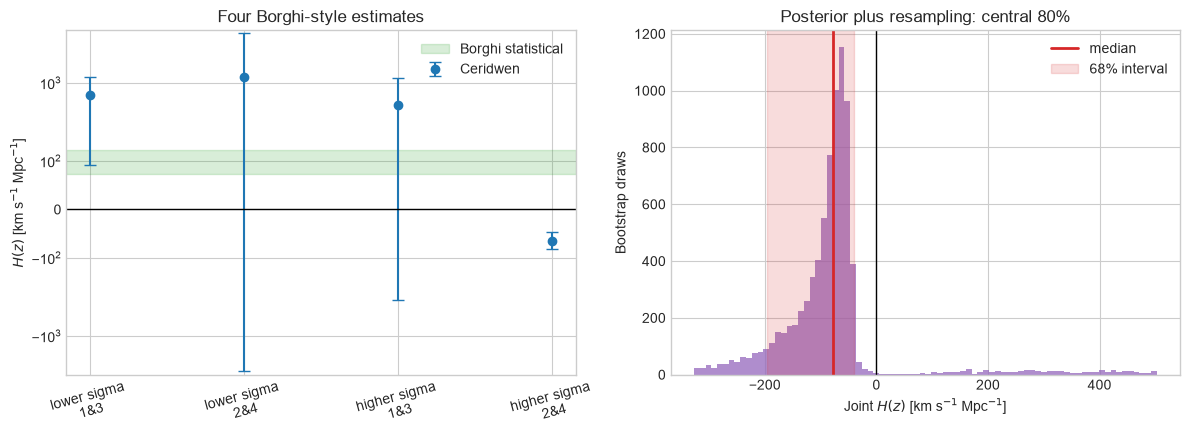

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(estimates))
axes[0].errorbar(x, estimates["H_km_s_Mpc"], yerr=estimates["sigma_H_km_s_Mpc"], fmt="o", capsize=4, label="Ceridwen")
axes[0].axhline(0, color="black", lw=1)
axes[0].axhspan(98.8 - 24.8, 98.8 + 24.8, color="tab:green", alpha=0.18, label="Borghi statistical")
axes[0].set_xticks(x, [f"{row.sigma_group}\n{row.bins}" for row in estimates.itertuples()], rotation=15)
axes[0].set_yscale("symlog", linthresh=150)
axes[0].set_ylabel(r"$H(z)$ [km s$^{-1}$ Mpc$^{-1}$]")
axes[0].set_title("Four Borghi-style estimates")
axes[0].legend()

finite = bootstrap_joint_h[np.isfinite(bootstrap_joint_h)]
plot_low, plot_high = np.quantile(finite, [0.10, 0.90])
axes[1].hist(finite[(finite >= plot_low) & (finite <= plot_high)], bins=80, color="tab:purple", alpha=0.75)
axes[1].axvline(0, color="black", lw=1)
axes[1].axvline(joint_q50, color="tab:red", lw=2, label="median")
axes[1].axvspan(joint_q16, joint_q84, color="tab:red", alpha=0.16, label="68% interval")
axes[1].set(xlabel=r"Joint $H(z)$ [km s$^{-1}$ Mpc$^{-1}$]", ylabel="Bootstrap draws", title="Posterior plus resampling: central 80%")
axes[1].legend()
fig.tight_layout()
plt.show()

## Test binning and estimator sensitivity

- Vary equal-width bin counts from two through six.
- Compare medians, means, and equal-population quartiles.

In [8]:
def variant_estimate(n_bins, estimator="median", equal_population=False):
    component_h = []
    component_error = []
    for sigma_group in ["lower sigma", "higher sigma"]:
        group = analysis.loc[analysis["sigma_group"] == sigma_group].copy()
        if equal_population:
            group["variant_bin"] = pd.qcut(group["redshift"], n_bins, labels=False) + 1
        else:
            edges = np.linspace(0.6, 0.9, n_bins + 1)
            group["variant_bin"] = pd.cut(group["redshift"], edges, labels=False, include_lowest=True, right=False) + 1
        summaries = []
        for bin_id, members in group.groupby("variant_bin", observed=True):
            ages = members["age_median_gyr"].to_numpy()
            center = np.median(ages) if estimator == "median" else np.mean(ages)
            scatter = median_abs_deviation(ages, scale="normal") if estimator == "median" else np.std(ages, ddof=1)
            summaries.append((int(bin_id), members["redshift"].median(), center, scatter / np.sqrt(len(ages))))
        table = pd.DataFrame(summaries, columns=["bin", "z", "age", "age_error"]).set_index("bin")
        separation = 1 if n_bins == 2 else 2
        for low_bin in range(1, n_bins - separation + 1):
            high_bin = low_bin + separation
            if low_bin not in table.index or high_bin not in table.index:
                continue
            low, high = table.loc[low_bin], table.loc[high_bin]
            _, hubble = hubble_from_age_difference(low.z, high.z, low.age, high.age)
            sigma_hubble = hubble_uncertainty_from_age_errors(hubble, high.age - low.age, low.age_error, high.age_error)
            component_h.append(hubble)
            component_error.append(sigma_hubble)
    return inverse_variance_combine(np.asarray(component_h), np.asarray(component_error))[0]

variant_rows = []
for n_bins in range(2, 7):
    for estimator in ["median", "mean"]:
        variant_rows.append({
            "variant": f"{n_bins} equal-width bins, {estimator}",
            "H_km_s_Mpc": variant_estimate(n_bins, estimator),
        })
for estimator in ["median", "mean"]:
    variant_rows.append({
        "variant": f"4 equal-population bins, {estimator}",
        "H_km_s_Mpc": variant_estimate(4, estimator, equal_population=True),
    })
variants = pd.DataFrame(variant_rows)
available_systematic = variants["H_km_s_Mpc"].std(ddof=1)
variants

,variant,H_km_s_Mpc
0,"2 equal-width bins, median",-87.692413
1,"2 equal-width bins, mean",-647.819168
2,"3 equal-width bins, median",-94.402623
3,"3 equal-width bins, mean",255.042018
4,"4 equal-width bins, median",-63.588986
5,"4 equal-width bins, mean",132.648868
6,"5 equal-width bins, median",-16.401802
7,"5 equal-width bins, mean",77.707646
8,"6 equal-width bins, median",-55.382925
9,"6 equal-width bins, mean",57.093653


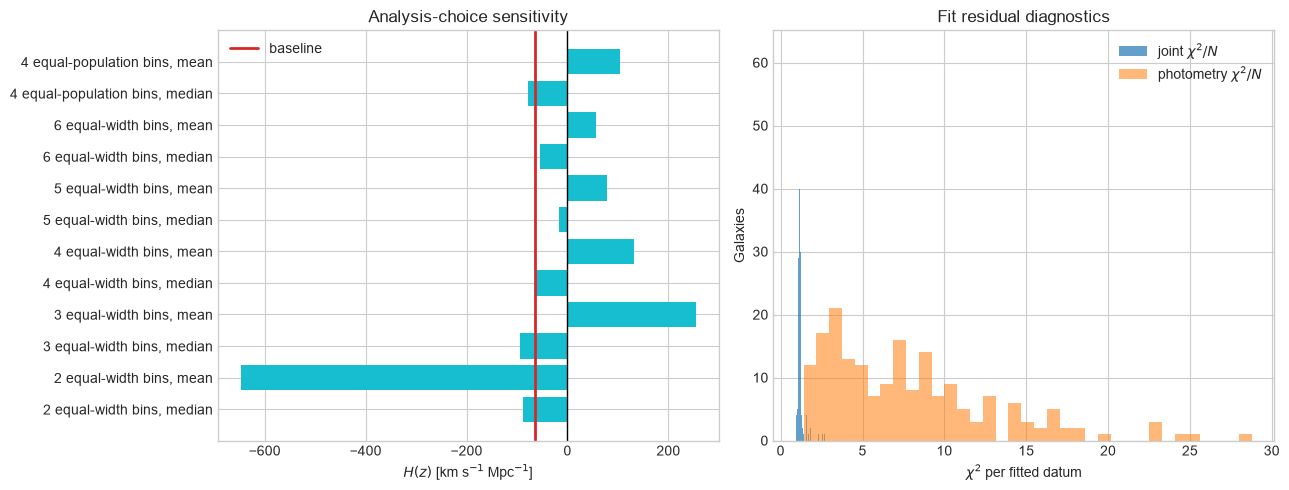

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(variants["variant"], variants["H_km_s_Mpc"], color="tab:cyan")
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(joint_h, color="tab:red", lw=2, label="baseline")
axes[0].set_xlabel(r"$H(z)$ [km s$^{-1}$ Mpc$^{-1}$]")
axes[0].set_title("Analysis-choice sensitivity")
axes[0].legend()

axes[1].hist(galaxies["joint_chi2_per_datum"], bins=35, alpha=0.7, label=r"joint $\chi^2/N$")
axes[1].hist(galaxies["photometry_chi2_per_datum"], bins=35, alpha=0.55, label=r"photometry $\chi^2/N$")
axes[1].set(xlabel=r"$\chi^2$ per fitted datum", ylabel="Galaxies", title="Fit residual diagnostics")
axes[1].legend()
fig.tight_layout()
plt.show()

## Save the aggregate numerical result

- Keep every reported table beside the embedded figures.
- Preserve bootstrap draws for later covariance analysis.

In [10]:
summary_path = RESULT_ROOT / "ceridwen_cosmic_chronometer_summary.h5"
string_dtype = h5py.string_dtype(encoding="utf-8")
with h5py.File(summary_path, "w") as output:
    output.attrs["schema_version"] = 1
    output.attrs["random_seed"] = SEED
    output.attrs["n_bootstrap"] = N_BOOTSTRAP
    output.attrs["sigma_split_km_s"] = SIGMA_SPLIT
    output.attrs["age_definition"] = "Ceridwen SFH mass-weighted lookback age"
    output.attrs["posterior_draw_rule"] = "one age draw per unique galaxy per bootstrap realization"
    output.attrs["cosmology_independent"] = False
    output.attrs["limitation"] = "SFH maximum equals Ceridwen age_gyr(catalogue redshift) under Planck-2018 defaults"
    output.create_dataset("z_edges", data=Z_EDGES)
    reference_group = output.create_group("borghi_2022_reference")
    for column in borghi_reference.columns:
        reference_group.create_dataset(column, data=borghi_reference[column].to_numpy())
    galaxy_group = output.create_group("galaxies")
    for column in galaxies.columns:
        values = galaxies[column].to_numpy()
        if values.dtype.kind in "OU":
            galaxy_group.create_dataset(column, data=np.asarray(values, dtype=object), dtype=string_dtype)
        else:
            galaxy_group.create_dataset(column, data=values)
    for name, frame in [("bins", binned), ("estimates", estimates), ("bootstrap_summary", bootstrap_summary), ("variants", variants)]:
        group = output.create_group(name)
        for column in frame.columns:
            values = frame[column].to_numpy()
            if values.dtype.kind in "OU":
                group.create_dataset(column, data=np.asarray(values, dtype=object), dtype=string_dtype)
            else:
                group.create_dataset(column, data=values)
    bootstrap_group = output.create_group("bootstrap")
    bootstrap_group.create_dataset("component_H_km_s_Mpc", data=bootstrap_h, compression="gzip")
    bootstrap_group.create_dataset("component_z_eff", data=bootstrap_z, compression="gzip")
    bootstrap_group.create_dataset("joint_H_km_s_Mpc", data=bootstrap_joint_h, compression="gzip")
    bootstrap_group.create_dataset("joint_z_eff", data=bootstrap_joint_z, compression="gzip")
    joint = output.create_group("joint")
    joint.attrs["z_eff"] = joint_z
    joint.attrs["H_km_s_Mpc"] = joint_h
    joint.attrs["sigma_stat_analytic_km_s_Mpc"] = joint_sigma
    joint.attrs["bootstrap_q16_km_s_Mpc"] = joint_q16
    joint.attrs["bootstrap_median_km_s_Mpc"] = joint_q50
    joint.attrs["bootstrap_q84_km_s_Mpc"] = joint_q84
    joint.attrs["bootstrap_positive_fraction"] = np.mean(bootstrap_joint_h > 0)
    joint.attrs["available_analysis_systematic_km_s_Mpc"] = available_systematic

print("Borghi reference: H(z=0.753) = 98.8 ± 24.8 km/s/Mpc statistical; ±33.6 total")
print(f"Validated Ceridwen fits: {len(galaxies)}/187")
print(f"Borghi-range galaxies: {len(analysis)}")
print(f"Analytic joint: H(z={joint_z:.3f}) = {joint_h:.1f} ± {joint_sigma:.1f} km/s/Mpc")
print(f"Posterior+bootstrap joint: {joint_q50:.1f} [{joint_q16:.1f}, {joint_q84:.1f}] km/s/Mpc")
print(f"Positive bootstrap fraction: {np.mean(bootstrap_joint_h > 0):.3f}")
print(f"Available binning/estimator systematic: {available_systematic:.1f} km/s/Mpc")
print("Conclusion: Ceridwen mass-weighted ages do not yield a stable positive age-redshift slope in these bins.")
print("Boundary: the fitted SFH age ceiling uses the Planck-2018 universe age, so this is not an independent H(z) measurement.")
summary_path

Borghi reference: H(z=0.753) = 98.8 ± 24.8 km/s/Mpc statistical; ±33.6 total
Validated Ceridwen fits: 187/187
Borghi-range galaxies: 164
Analytic joint: H(z=0.741) = -63.6 ± 17.8 km/s/Mpc
Posterior+bootstrap joint: -77.4 [-196.3, -39.9] km/s/Mpc
Positive bootstrap fraction: 0.146
Available binning/estimator systematic: 221.2 km/s/Mpc
Conclusion: Ceridwen mass-weighted ages do not yield a stable positive age-redshift slope in these bins.
Boundary: the fitted SFH age ceiling uses the Planck-2018 universe age, so this is not an independent H(z) measurement.


PosixPath('/Users/liuhao/Downloads/Astro project/results/rtx-5060-dr2-quiescent-full-spectrum/ceridwen_cosmic_chronometer_summary.h5')